In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/Object Detection in ocean.v2i.yolov8.zip" -d "/content/dataset"



Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/train/labels/P0132_600_1400_5400_6200_png.rf.a33cd89a0796ac7d219efe879abe6acc.txt  
  inflating: /content/dataset/train/labels/001026_jpg.rf.034ab90d18135ff81a6e83805f8664bf.txt  
  inflating: /content/dataset/train/labels/P0058_0_800_5200_6000_png.rf.f8a4e5b735ba367d27fdc957f5ad9b50.txt  
  inflating: /content/dataset/train/labels/000210_jpg.rf.35efe97606bd5d5ffa9f112463d52aeb.txt  
  inflating: /content/dataset/train/labels/P0012_4800_5600_0_800_png.rf.7126eadd4db2b5ce3d42a04330c7893a.txt  
  inflating: /content/dataset/train/labels/P0035_1800_2600_1200_2000_png.rf.792038531b8529d1b0ea2c84c1260926.txt  
  inflating: /content/dataset/train/labels/P0080_600_1400_1200_2000_png.rf.8d99196bd13a073d7cd3f13e633ab7b8.txt  
  inflating: /content/dataset/train/labels/P0049_600_1400_4800_5600_png.rf.e97d8bfbedffa346d39b8fc103bc57ff.txt  
  inflating: /content/dataset/train/labels/P0066_3900_4700_1200_2000_png.rf.df

In [ ]:
!ls /content/dataset


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [14]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    name='sar_particle_detection'
)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sar_particle_detection-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ec1543852e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

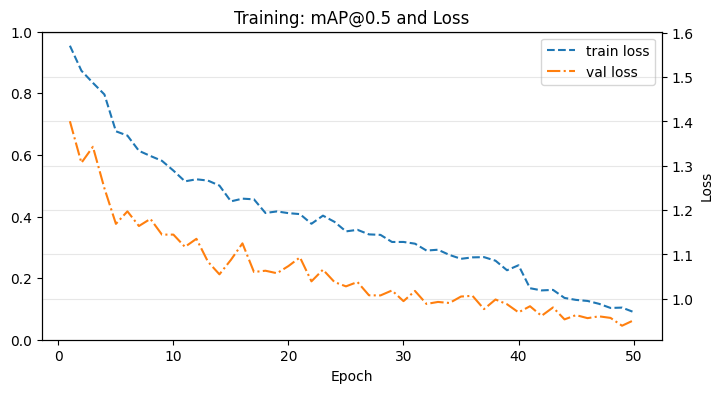

In [16]:
import os, pandas as pd, matplotlib.pyplot as plt
run_path = "/content/runs/detect/sar_particle_detection-3/"   # ← change to your run folder or to the folder that contains metrics.csv
# try common filenames
for fname in ("metrics.csv","results.csv","results.json"):
    fp = os.path.join(run_path, fname)
    if os.path.isfile(fp):
        if fp.endswith(".json"):
            df = pd.read_json(fp)
        else:
            df = pd.read_csv(fp)
        break
else:
    raise FileNotFoundError("No metrics file found. Put metrics.csv in run_path or update run_path.")
# normalize column names
cols = [c.lower() for c in df.columns]
df.columns = cols
# pick columns (best-effort)
epochs = df.get("epoch", pd.Series(range(1,len(df)+1)))
map50 = df.get("map_0.5") or df.get("map50") or df.get("m_ap_0.5") or df.get("metrics/mAP_0.5") or df.get("map@0.5")
train_loss = df.get("train_loss") or df.get("loss") or df.get("train/box_loss")
val_loss = df.get("val_loss") or df.get("validation_loss") or df.get("val/box_loss")
plt.figure(figsize=(8,4))
ax = plt.gca()
if map50 is not None:
    ax.plot(epochs, map50, marker='o', label="mAP@0.5")
    ax.set_ylabel("mAP@0.5")
ax2 = ax.twinx()
if train_loss is not None:
    ax2.plot(epochs, train_loss, linestyle='--', label="train loss")
if val_loss is not None:
    ax2.plot(epochs, val_loss, linestyle='-.', label="val loss")
ax2.set_ylabel("Loss")
ax.set_xlabel("Epoch")
lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="best")
plt.title("Training: mAP@0.5 and Loss")
plt.grid(alpha=0.3)
plt.show()

In [17]:
!ls /content/runs/detect/sar_particle_detection/weights


In [20]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/sar_particle_detection-3/weights/best.pt')

In [22]:
from ultralytics import YOLO

In [23]:
model = YOLO("yolov8n.pt")  # choose small model, you can also use yolov8s.pt or yolov8m.pt

In [4]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/sar_particle_detection-3/weights/best.pt')
results = model.predict(source='/content/dataset/test/images', conf=0.25)


image 1/672 /content/dataset/test/images/000003_jpg.rf.873e163323fd0219e49b49507ff1ebe4.jpg: 640x640 1 ship, 9.3ms
image 2/672 /content/dataset/test/images/000047_jpg.rf.fb935187752e67d1e93736ba8fbdda22.jpg: 640x640 2 ships, 6.0ms
image 3/672 /content/dataset/test/images/000059_jpg.rf.03598be56ceb2acaa47b2e89234a5efa.jpg: 640x640 5 ships, 5.6ms
image 4/672 /content/dataset/test/images/000062_jpg.rf.e4ec900722449833cc2b5403f60e8738.jpg: 640x640 1 ship, 6.8ms
image 5/672 /content/dataset/test/images/000069_jpg.rf.fd82141820992d960f0c857d14eff091.jpg: 640x640 1 ship, 5.7ms
image 6/672 /content/dataset/test/images/000086_jpg.rf.04451fb17c05df687962a0268327f862.jpg: 640x640 1 ship, 5.6ms
image 7/672 /content/dataset/test/images/000096_jpg.rf.28077c35ea91ca8fad248916064b0f27.jpg: 640x640 1 ship, 5.6ms
image 8/672 /content/dataset/test/images/000097_jpg.rf.9b08e96b5e883520aa090970fd17de8c.jpg: 640x640 3 ships, 5.6ms
image 9/672 /content/dataset/test/images/000102_jpg.rf.f2f31dc2d6be9605b850a

In [5]:
model.info()

Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


(73, 3005843, 0, 8.0851968)

In [9]:
results = model.predict(
    source="/content/dataset/test/images",
    conf=0.25,
    save=True
)


image 1/672 /content/dataset/test/images/000003_jpg.rf.873e163323fd0219e49b49507ff1ebe4.jpg: 640x640 1 ship, 19.7ms
image 2/672 /content/dataset/test/images/000047_jpg.rf.fb935187752e67d1e93736ba8fbdda22.jpg: 640x640 2 ships, 7.2ms
image 3/672 /content/dataset/test/images/000059_jpg.rf.03598be56ceb2acaa47b2e89234a5efa.jpg: 640x640 5 ships, 7.2ms
image 4/672 /content/dataset/test/images/000062_jpg.rf.e4ec900722449833cc2b5403f60e8738.jpg: 640x640 1 ship, 7.2ms
image 5/672 /content/dataset/test/images/000069_jpg.rf.fd82141820992d960f0c857d14eff091.jpg: 640x640 1 ship, 7.2ms
image 6/672 /content/dataset/test/images/000086_jpg.rf.04451fb17c05df687962a0268327f862.jpg: 640x640 1 ship, 7.2ms
image 7/672 /content/dataset/test/images/000096_jpg.rf.28077c35ea91ca8fad248916064b0f27.jpg: 640x640 1 ship, 7.2ms
image 8/672 /content/dataset/test/images/000097_jpg.rf.9b08e96b5e883520aa090970fd17de8c.jpg: 640x640 3 ships, 7.2ms
image 9/672 /content/dataset/test/images/000102_jpg.rf.f2f31dc2d6be9605b850


image 1/672 /content/dataset/test/images/000003_jpg.rf.873e163323fd0219e49b49507ff1ebe4.jpg: 640x640 1 ship, 7.4ms
image 2/672 /content/dataset/test/images/000047_jpg.rf.fb935187752e67d1e93736ba8fbdda22.jpg: 640x640 2 ships, 7.8ms
image 3/672 /content/dataset/test/images/000059_jpg.rf.03598be56ceb2acaa47b2e89234a5efa.jpg: 640x640 5 ships, 7.5ms
image 4/672 /content/dataset/test/images/000062_jpg.rf.e4ec900722449833cc2b5403f60e8738.jpg: 640x640 1 ship, 7.4ms
image 5/672 /content/dataset/test/images/000069_jpg.rf.fd82141820992d960f0c857d14eff091.jpg: 640x640 1 ship, 7.4ms
image 6/672 /content/dataset/test/images/000086_jpg.rf.04451fb17c05df687962a0268327f862.jpg: 640x640 1 ship, 7.5ms
image 7/672 /content/dataset/test/images/000096_jpg.rf.28077c35ea91ca8fad248916064b0f27.jpg: 640x640 1 ship, 7.4ms
image 8/672 /content/dataset/test/images/000097_jpg.rf.9b08e96b5e883520aa090970fd17de8c.jpg: 640x640 3 ships, 7.2ms
image 9/672 /content/dataset/test/images/000102_jpg.rf.f2f31dc2d6be9605b850a

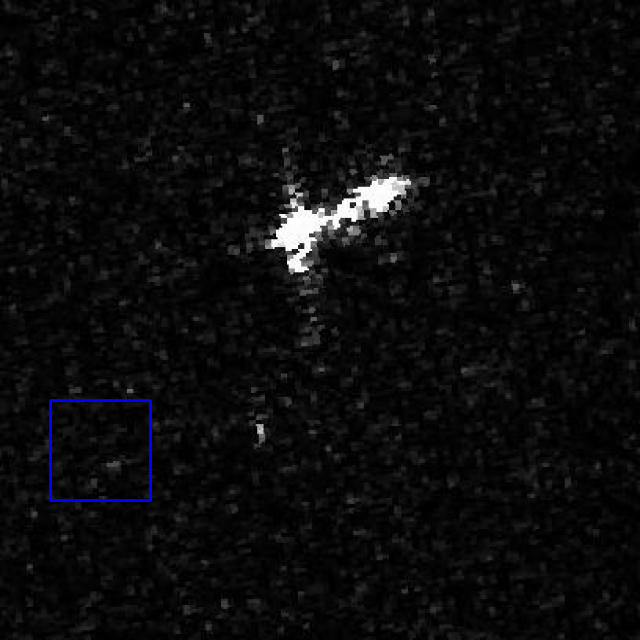

In [11]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

# Re-initialize model and perform prediction to ensure 'results' is defined
model = YOLO('/content/runs/detect/sar_particle_detection-3/weights/best.pt')
results = model.predict(source='/content/dataset/test/images', conf=0.25)

image_with_box = results[6].orig_img.copy()
#  EXTRACT BOUNDING BOX COORDINATES
x_min = 50   # Top-Left X
y_min = 400  # Top-Left Y
x_max = 150  # Bottom-Right X
y_max = 500  # Bottom-Right Y
#  DRAW THE RECTANGLE
color = (255, 0, 0) # Green color in BGR format
thickness = 2
# Draw the rectangle on the 'image_with_box' variable
cv2.rectangle(image_with_box, (x_min, y_min), (x_max, y_max), color, thickness)
#DISPLAY THE RESULT
cv2_imshow(image_with_box)